## AGN Homework 6 – Fantastically Fitting FANTASY Spectra

In [1]:
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)

import numpy as np
import pandas as pd

import glob

#### Define Targets

| Plate |  MJD  | FiberID |
|-------|-------|---------|
| 11279 | 58449 |   978   |
|  7596 | 56945 |   162   |
|  4216 | 55477 |   310   |

In [2]:
from fantasy_agn.tools import read_sdss, read_text, read_gama_fits

from fantasy_agn.models import create_input_folder

from fantasy_agn.models import create_feii_model, create_model, create_tied_model, continuum, create_line, create_fixed_model

In [3]:
specs = ['spec-4216-55477-0310', 'spec-7750-58402-0802', 'spec-11279-58449-0978']

print()
create_input_folder(xmin=2000,xmax=8000, path_to_folder='lists')
print()
!ls lists
print()


Directory  lists  already exists

balmer.csv   feII_forbidden.csv  helium.csv	   narrow_plus.csv
broad.csv    feii_IZw1.csv	 hydrogen.csv	   oiii_nii.csv
coronal.csv  feII_model.csv	 narrow_basic.csv  uvfe.csv




Host contribution is negliglable



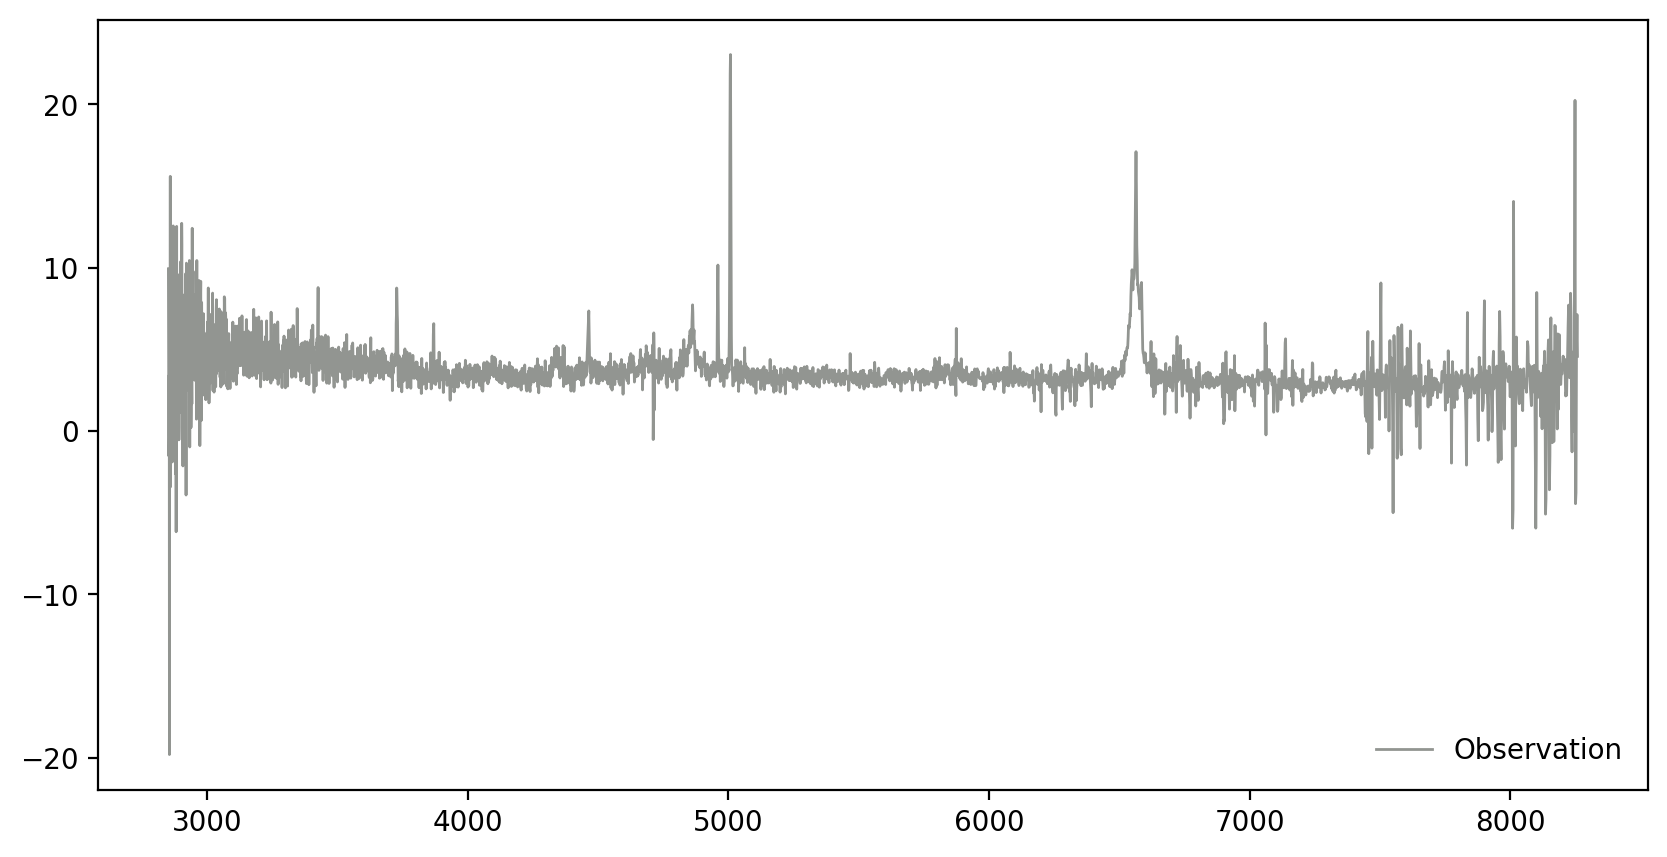

CROPPING...

min: 3500.17
max: 6999.91
len: 3011

FITTING...

iteration:  1
iteration:  2

PLOTTING...



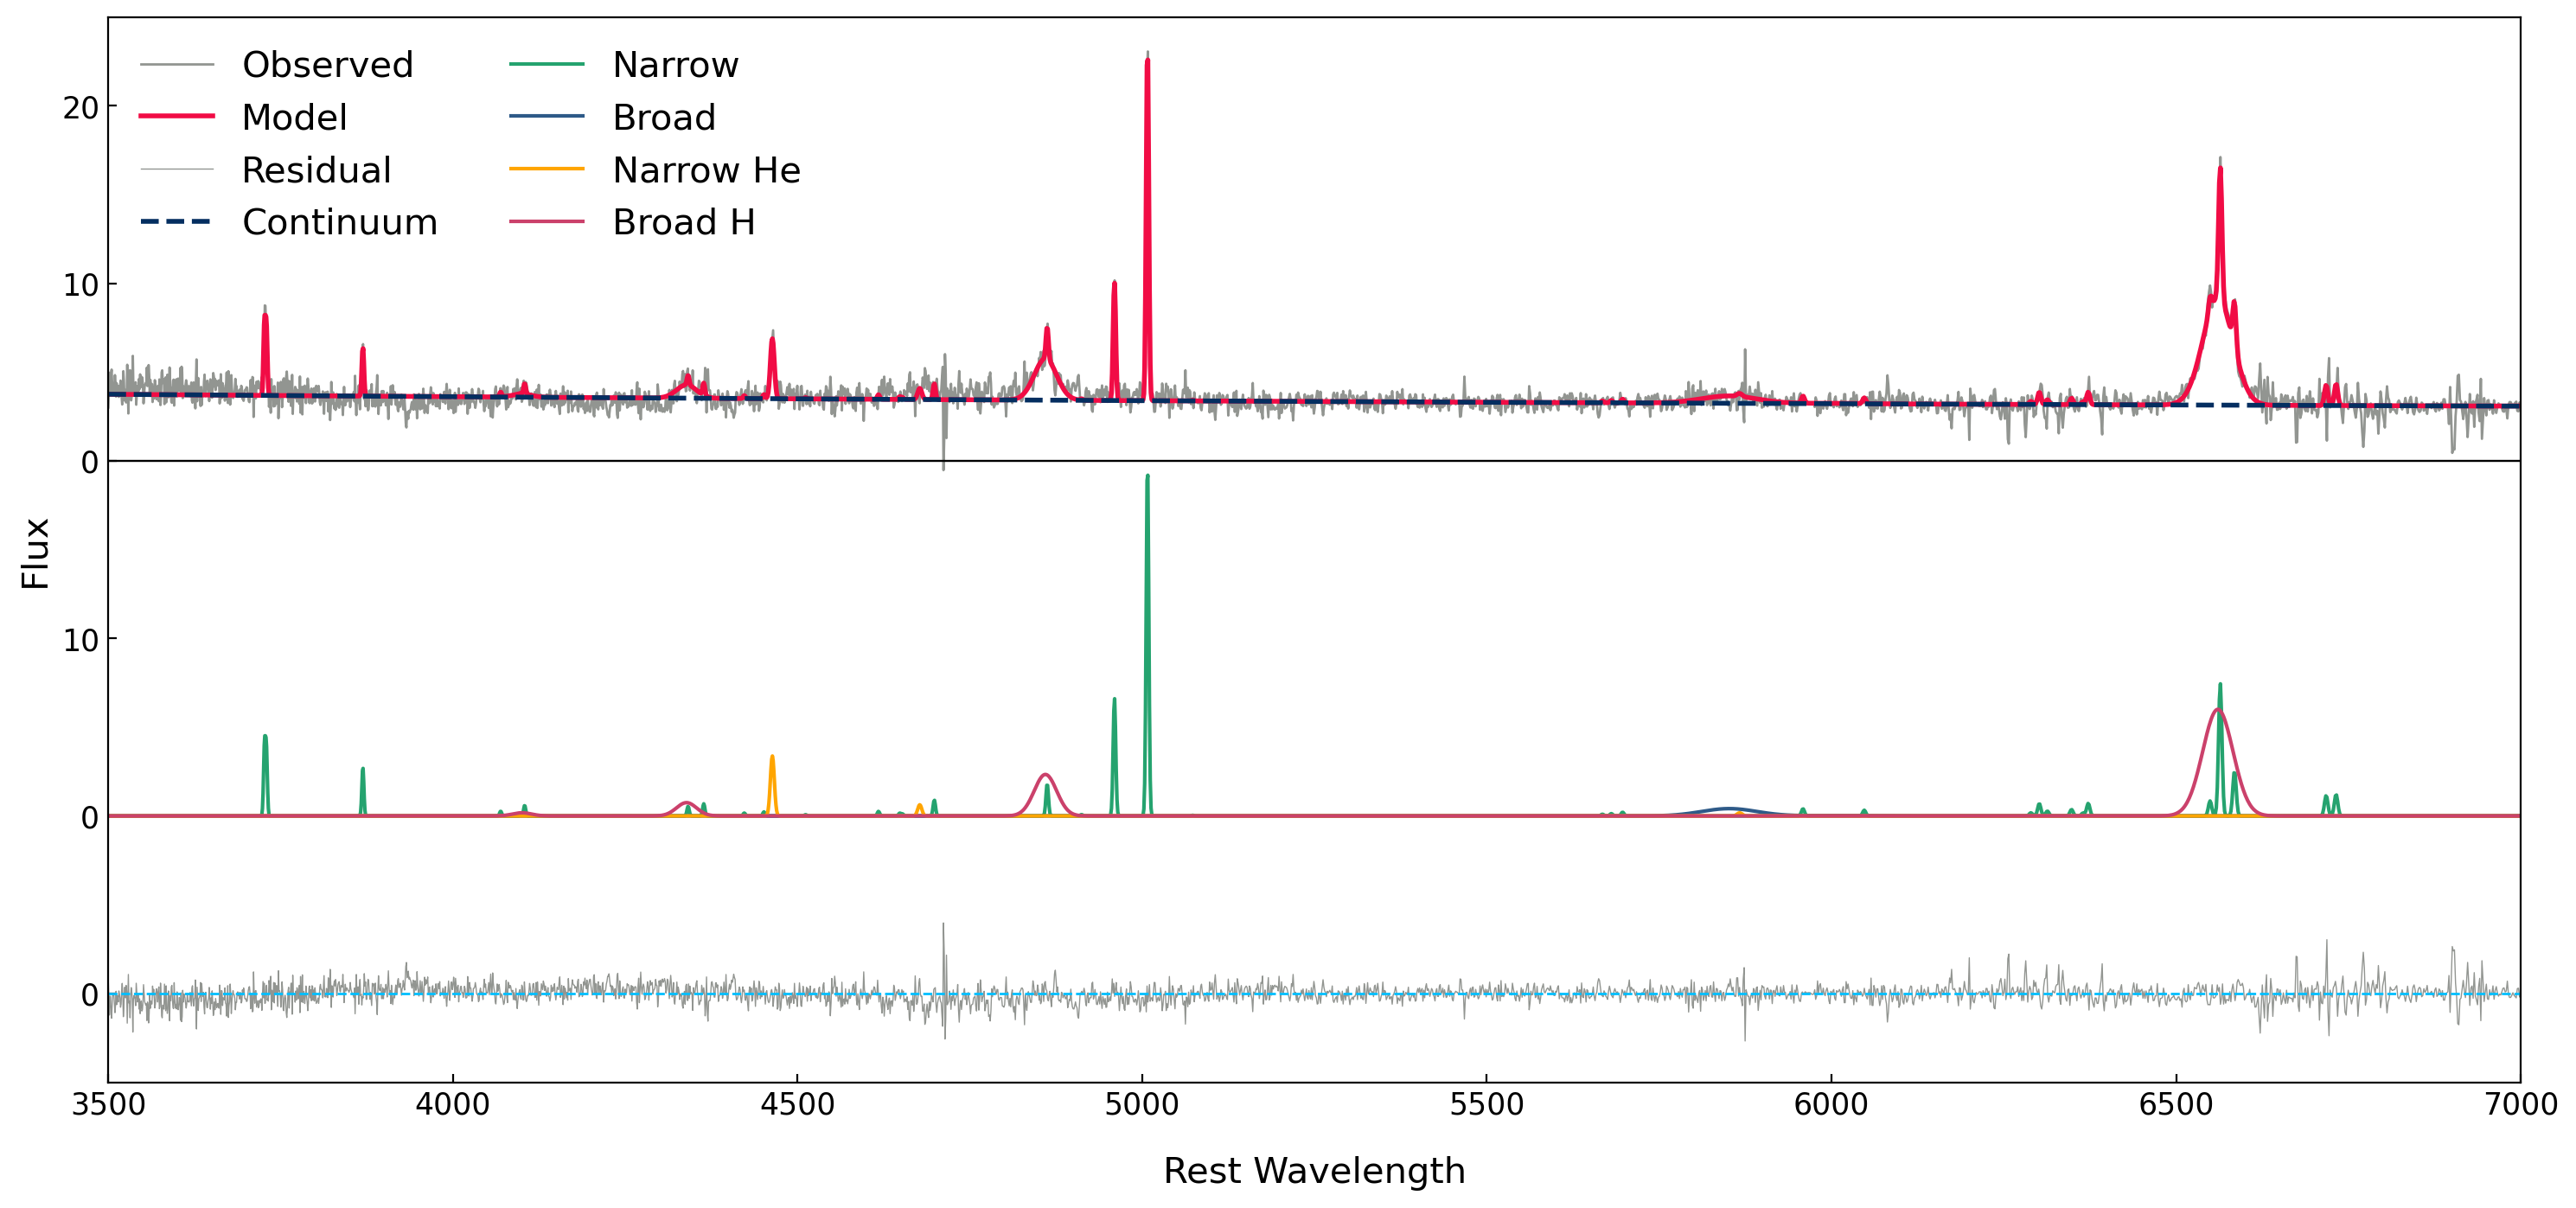

In [4]:
s=read_sdss(f'spectra/{specs[0]}.fits')

s.DeRedden()

s.CorRed()

print()
s.fit_host_sdss(mask_host=True, custom=False)
print()

plt.style.context(['nature', 'notebook'])
plt.figure(figsize=(10,5))
plt.plot(s.wave, s.flux, color="#929591", label='Observation', lw=1)
plt.legend(loc='lower right',  prop={'size': 10}, frameon=False, ncol=2)

plt.show()
plt.close()

print('CROPPING...')
s.crop(3500, 7000)
print(f'\nmin: {min(s.wave):.2f}\nmax: {max(s.wave):.2f}\nlen: {len(s.wave)}\n')

cont=continuum(s)
broad=create_fixed_model(['broad.csv'], name='br')
br_h=create_fixed_model(['hydrogen.csv'], name='br')
narrow=create_tied_model(name='OIII5007',files=['narrow_basic.csv','narrow_plus.csv','hydrogen.csv'],prefix='nr', fwhm=1000,min_offset=0, max_offset=300, min_fwhm=200, max_fwhm=1800, fix_oiii_ratio=True, position=5006.803341, included=True)
nr_he=create_fixed_model(['helium.csv'], name='he',fwhm=250, min_fwhm=50, max_fwhm=450)
fe=create_feii_model(name='feii', fwhm=1800, min_fwhm=1000, max_fwhm=2600, offset=0, min_offset=-3000, max_offset=3000)

model = cont+broad+br_h+narrow+nr_he#fe+he

print('FITTING...\n')
s.fit(model, ntrial=2)
print('\nPLOTTING...\n')

plt.style.context(['nature', 'notebook'])
plt.figure(figsize=(18,8))
plt.plot(s.wave, s.flux, label='Observed', color="#929591", lw=1)
plt.plot(s.wave, model(s.wave), label='Model', color="#F10C45", lw=2)
plt.axhline(y=0, color='black', linestyle='-', lw=0.85)
plt.plot(s.wave, model(s.wave) - s.flux - 30, '-', label='Residual', color="#929591", lw=0.5)
plt.axhline(y=-30, color='deepskyblue', linestyle='--', lw=1)

plt.plot(s.wave, cont(s.wave), '--', label='Continuum', color="#042E60", lw=2)
plt.plot(s.wave, narrow(s.wave) - 20, label='Narrow', color="#25A36F", lw=1.5)
plt.plot(s.wave, broad(s.wave) - 20, label='Broad', color="#2E5A88", lw=1.5)
plt.plot(s.wave, nr_he(s.wave) - 20, label='Narrow He', color="orange", lw=1.5)
plt.plot(s.wave, br_h(s.wave) - 20, '-', label='Broad H', color="#CB416B", lw=1.5)

plt.xlabel('Rest Wavelength',fontsize=15, labelpad=15)
plt.ylabel('Flux',fontsize=15)
plt.xlim(3500,7000)
plt.ylim(-35,25)
plt.tick_params(which='both', direction="in")
plt.xticks(np.arange(3500, 7500, 500), fontsize=12.5)
plt.yticks(np.arange(-30, 30, 10), ['0', '0', '10', '0', '10', '20'], fontsize=12.5)
plt.legend(loc='upper left',  prop={'size': 15}, frameon=False, ncol=2)

plt.show()
plt.close()